
[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\peddi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\peddi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\peddi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\peddi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                _index      _type      _id  _score   _source.tags  \
0  complaint-public-v2  complaint  3211475     0.0           None   
1  complaint-public-v2  complaint  3229299     0.0  Servicemember   
2  complaint-public-v2  complaint  3199379     0.0           None   
3  complaint-public-v2  complaint  2673060     0.0           None   
4  complaint-public-v2  complaint  3203545     0.0           None   

  _source.zip_code _source.complaint_id                       _source.issue  \
0            90301              3211475   Attempts to collect debt not owed   
1            319XX              3229299     Written notification about debt   
2            77069              3199379  Other features, terms, or problems   
3            48066              2673060      Trouble during payment process   
4            10473              3203545                    Fees or interest   

       _source.date_received _source.state  ... _source.company_response  \
0  2019-04-13T12:00:00-05:00      

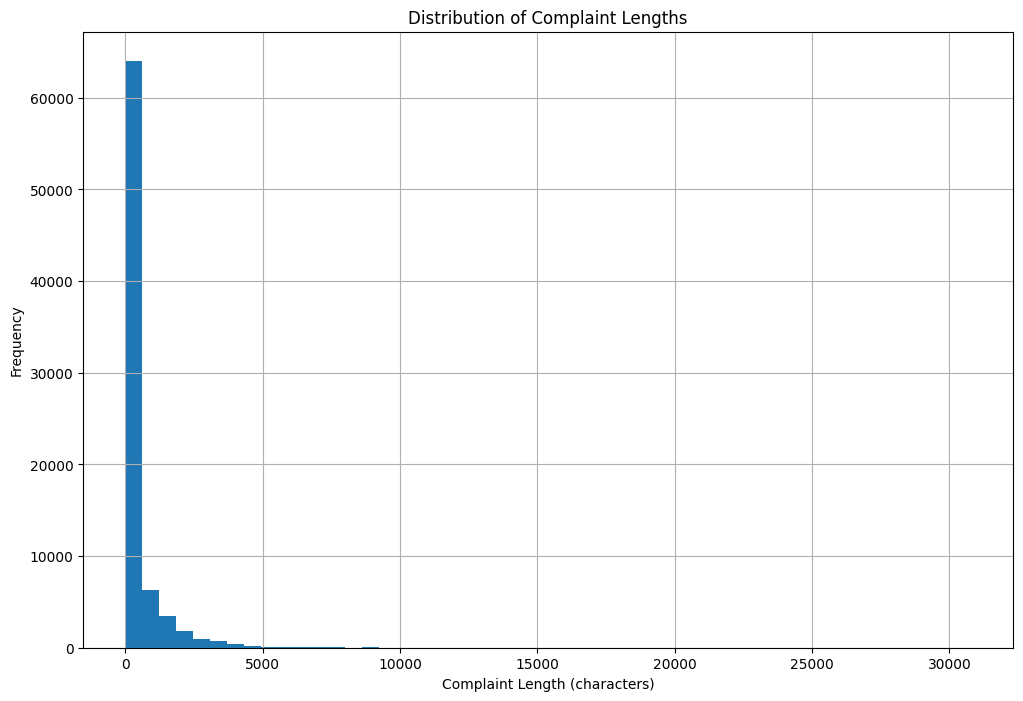

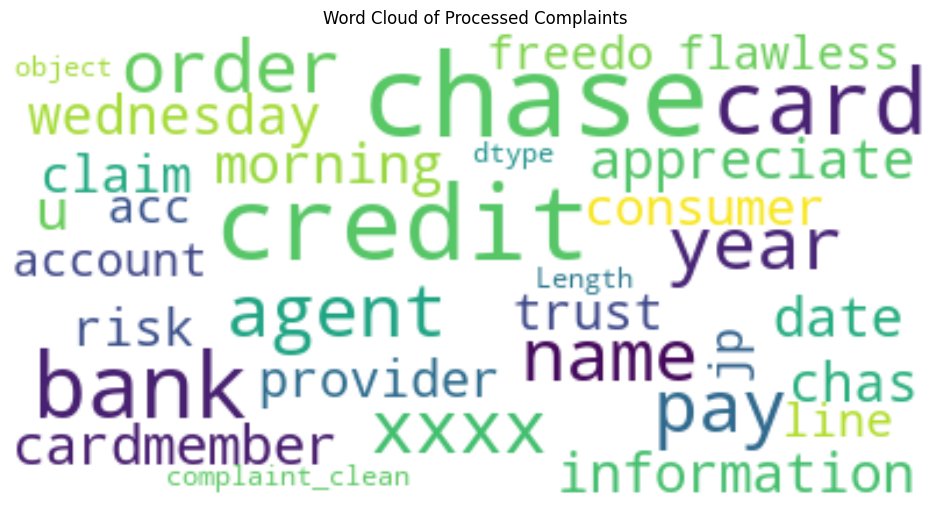

C:\Users\peddi\AppData\Local\Temp\ipykernel_11184\1719812928.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Unigram', y='Count', data=unigram_df, palette="Blues_d")


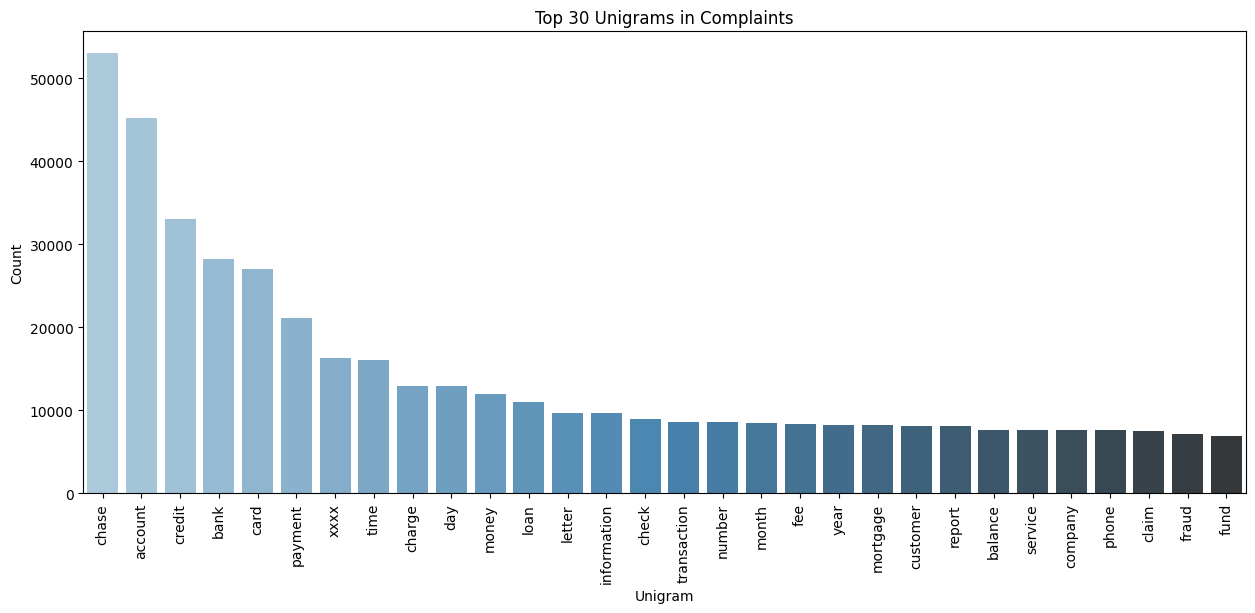

C:\Users\peddi\AppData\Local\Temp\ipykernel_11184\1719812928.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Bigram', y='Count', data=bigram_df, palette="Blues_d")


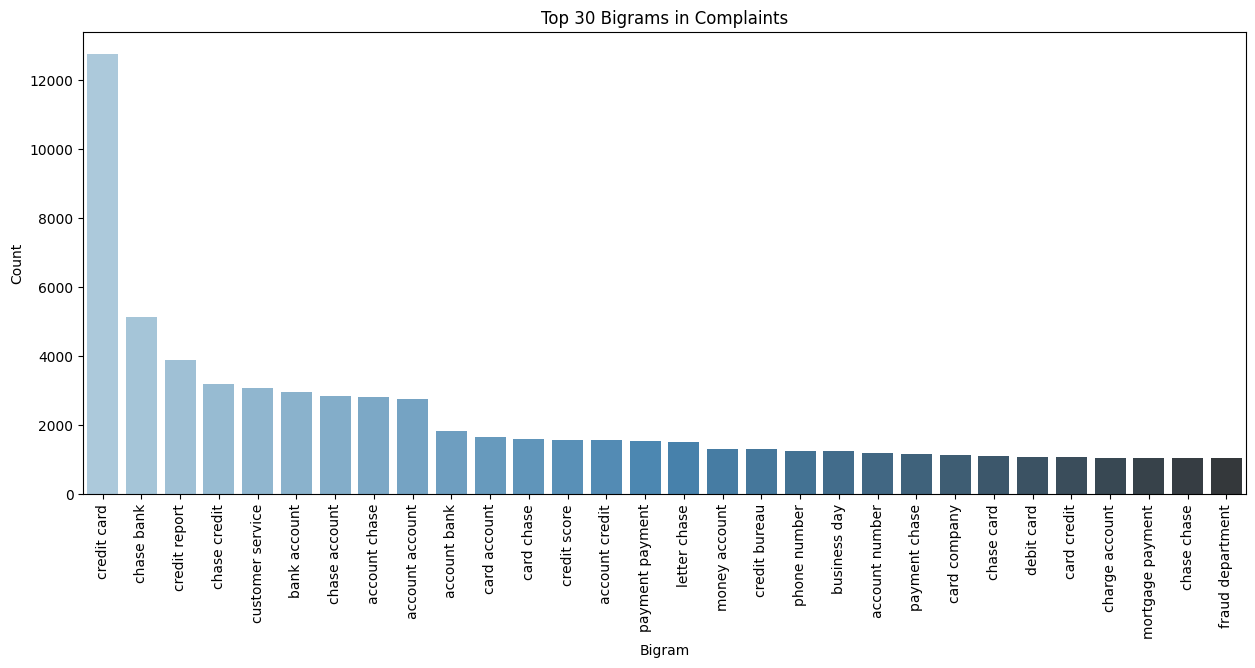

C:\Users\peddi\AppData\Local\Temp\ipykernel_11184\1719812928.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Trigram', y='Count', data=trigram_df, palette="Blues_d")


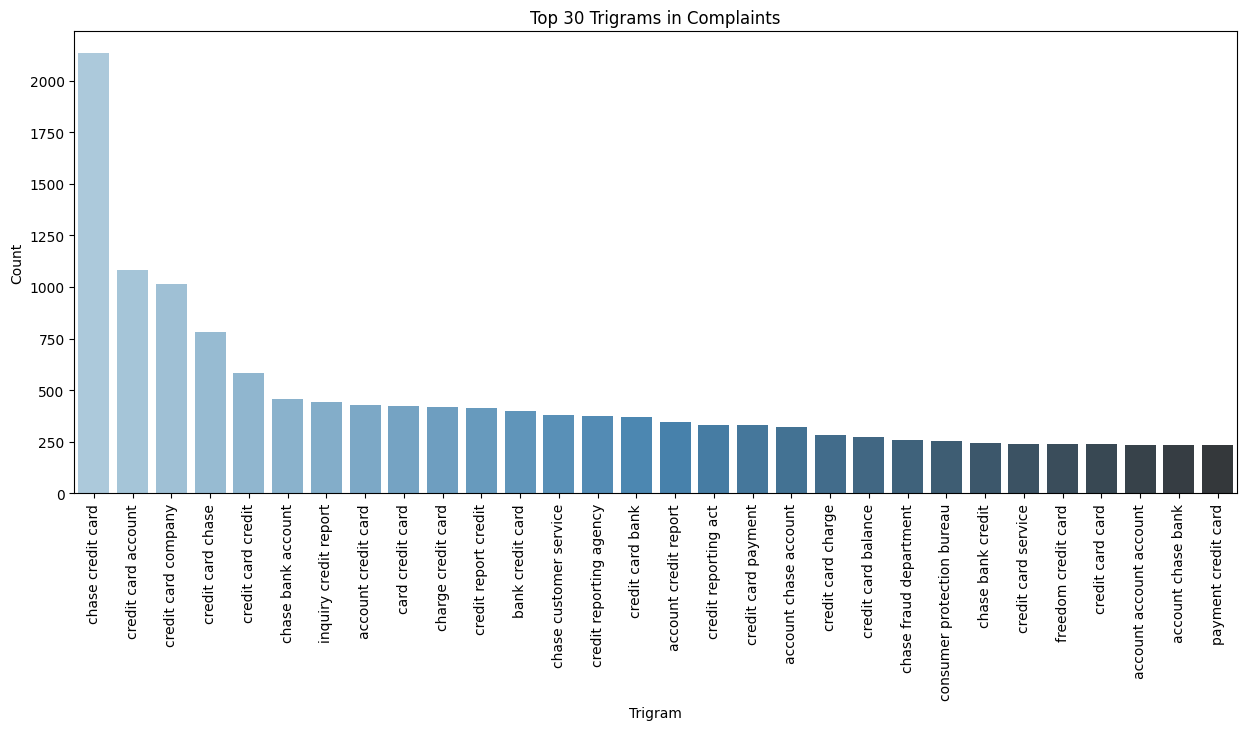

In [1]:
import json
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from wordcloud import WordCloud, STOPWORDS
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Install wordcloud if it's not already installed
!pip install wordcloud

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

# Load the data from JSON
file_path = 'complaints-2021-05-14_08_16.json'  # Adjust the file path
with open(file_path, 'r') as f:
    data = json.load(f)

df = pd.json_normalize(data)

# Check the initial structure of the dataframe
print(df.head())

# Handle missing data by filling or dropping columns
# We drop columns that have too much missing data (e.g., more than 50%)
df = df.dropna(thresh=len(df) * 0.5, axis=1)

# For the columns with missing values that we keep, we can either fill with placeholders or drop rows
df['_source.complaint_what_happened'].dropna(inplace=True)  # Ensures no missing complaints text

# Clean the complaints column by removing any unwanted characters and text
def clean_text(text):
    text = text.lower()  # Convert to lower case
    text = text.strip()  # Remove leading and trailing whitespaces
    text = re.sub(r"[\[].*?[\]]", "", text)  # Remove content inside brackets
    text = re.sub(r"[^\w\s]", "", text)  # Remove punctuation
    text = re.sub(r"\S*\d\S*", "", text)  # Remove words containing numbers
    return text

# Apply cleaning function to the '_source.complaint_what_happened' column
df['_source.complaint_what_happened'] = df['_source.complaint_what_happened'].apply(clean_text)

# Lemmatization function
def lemmatize_text(text):
    stop_words = set(stopwords.words('english'))
    wordnet_lem = WordNetLemmatizer()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    lemmatized_tokens = [wordnet_lem.lemmatize(word) for word in tokens]
    return ' '.join(lemmatized_tokens)

# Lemmatize the complaints
df['lemmatized_complaint'] = df['_source.complaint_what_happened'].apply(lemmatize_text)

# Function to extract only nouns using POS tagging
def extract_nouns(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    nouns = [word for word, tag in tagged if tag == "NN"]
    return ' '.join(nouns)

# Remove non-nouns (POS tags) from complaints
df['complaint_POS_removed'] = df['lemmatized_complaint'].apply(extract_nouns)

# Clean data by removing '-PRON-' which is commonly used for pronouns
df['complaint_clean'] = df['complaint_POS_removed'].str.replace('-PRON-', '', regex=False)

# View the cleaned data
print(df.head())

# Length distribution of complaints
df['complaint_length'] = df['_source.complaint_what_happened'].apply(len)

# Plotting the distribution of complaint lengths
plt.figure(figsize=(12, 8))
df['complaint_length'].hist(bins=50)
plt.title("Distribution of Complaint Lengths")
plt.xlabel("Complaint Length (characters)")
plt.ylabel("Frequency")
plt.show()

# Word cloud for the most frequent words in the processed complaints
word_cloud = WordCloud(
    background_color='white',
    stopwords=STOPWORDS,
    max_font_size=50,
    max_words=50,
    random_state=42
).generate(str(df['complaint_clean']))

plt.figure(figsize=(12, 8))
plt.imshow(word_cloud, interpolation="bilinear")
plt.axis('off')
plt.title("Word Cloud of Processed Complaints")
plt.show()

# Function to get the top n unigrams (single words)
def get_top_unigrams(text_data, n=30):
    vectorizer = CountVectorizer(stop_words='english')
    X = vectorizer.fit_transform(text_data)
    unigram_counts = X.sum(axis=0).A1
    unigram_freq = [(word, unigram_counts[idx]) for word, idx in vectorizer.vocabulary_.items()]
    unigram_freq = sorted(unigram_freq, key=lambda x: x[1], reverse=True)
    return unigram_freq[:n]

# Get and plot the top 30 unigrams
top_unigrams = get_top_unigrams(df['complaint_clean'])
unigram_df = pd.DataFrame(top_unigrams, columns=['Unigram', 'Count'])

# Plot the top 30 unigrams
plt.figure(figsize=(15, 6))
sns.barplot(x='Unigram', y='Count', data=unigram_df, palette="Blues_d")
plt.xticks(rotation=90)
plt.title("Top 30 Unigrams in Complaints")
plt.show()

# Function to get the top n bigrams
def get_top_bigrams(text_data, n=30):
    vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')
    X = vectorizer.fit_transform(text_data)
    bigram_counts = X.sum(axis=0).A1
    bigram_freq = [(word, bigram_counts[idx]) for word, idx in vectorizer.vocabulary_.items()]
    bigram_freq = sorted(bigram_freq, key=lambda x: x[1], reverse=True)
    return bigram_freq[:n]

# Get and plot the top 30 bigrams
top_bigrams = get_top_bigrams(df['complaint_clean'])
bigram_df = pd.DataFrame(top_bigrams, columns=['Bigram', 'Count'])

# Plot the top 30 bigrams
plt.figure(figsize=(15, 6))
sns.barplot(x='Bigram', y='Count', data=bigram_df, palette="Blues_d")
plt.xticks(rotation=90)
plt.title("Top 30 Bigrams in Complaints")
plt.show()

# Function to get the top n trigrams
def get_top_trigrams(text_data, n=30):
    vectorizer = CountVectorizer(ngram_range=(3, 3), stop_words='english')
    X = vectorizer.fit_transform(text_data)
    trigram_counts = X.sum(axis=0).A1
    trigram_freq = [(word, trigram_counts[idx]) for word, idx in vectorizer.vocabulary_.items()]
    trigram_freq = sorted(trigram_freq, key=lambda x: x[1], reverse=True)
    return trigram_freq[:n]

# Get and plot the top 30 trigrams
top_trigrams = get_top_trigrams(df['complaint_clean'])
trigram_df = pd.DataFrame(top_trigrams, columns=['Trigram', 'Count'])

# Plot the top 30 trigrams
plt.figure(figsize=(15, 6))
sns.barplot(x='Trigram', y='Count', data=trigram_df, palette="Blues_d")
plt.xticks(rotation=90)
plt.title("Top 30 Trigrams in Complaints")
plt.show()


In [2]:
# Ensure df_clean is properly initialized as a copy of the main dataframe (df)
df_clean = df.copy()

# Clean the 'xxxx' masked texts from 'complaint_clean' and 'complaint_POS_removed'
df_clean['complaint_clean'] = df_clean['complaint_clean'].str.replace('xxxx', '', regex=False)
df_clean['complaint_POS_removed'] = df_clean['complaint_POS_removed'].str.replace('xxxx', '', regex=False)

# Display the first 10 rows of cleaned data
print(df_clean.head(10))

# Display the shape of df_clean
print("Shape of df_clean:", df_clean.shape)

# Initializing the TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    min_df=2,                # Minimum document frequency (words must appear in at least 2 documents)
    max_df=0.95,             # Maximum document frequency (ignore words that appear in more than 95% of the documents)
    stop_words='english',    # Remove common stop words like 'the', 'is', 'and', etc.
    max_features=5000,       # Limit to top 5000 most important features (terms)
    ngram_range=(1, 3)       # Consider unigrams, bigrams, and trigrams (1 to 3 words)
)

# Creating the Document-Term Matrix (DTM) by transforming the 'complaint_POS_removed' column
tfidf = tfidf_vectorizer.fit_transform(df_clean['complaint_POS_removed'])

# Get the feature names (terms) generated by the TF-IDF vectorizer
features = tfidf_vectorizer.get_feature_names_out()

# Creating a DataFrame to display the Document-Term Matrix (DTM)
tfidf_df = pd.DataFrame(tfidf.toarray(), columns=features)

# Display the first few rows of the DTM
print(tfidf_df.head())

# Check the shape of the DTM
print("Shape of the Document-Term Matrix:", tfidf_df.shape)


                _index      _type      _id  _score _source.zip_code  \
0  complaint-public-v2  complaint  3211475     0.0            90301   
1  complaint-public-v2  complaint  3229299     0.0            319XX   
2  complaint-public-v2  complaint  3199379     0.0            77069   
3  complaint-public-v2  complaint  2673060     0.0            48066   
4  complaint-public-v2  complaint  3203545     0.0            10473   
5  complaint-public-v2  complaint  3275312     0.0            48227   
6  complaint-public-v2  complaint  3238804     0.0            76262   
7  complaint-public-v2  complaint  3249272     0.0            07753   
8  complaint-public-v2  complaint  3351653     0.0            60621   
9  complaint-public-v2  complaint  3273612     0.0            99354   

  _source.complaint_id                       _source.issue  \
0              3211475   Attempts to collect debt not owed   
1              3229299     Written notification about debt   
2              3199379  Other fe

In [3]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import numpy as np
import pandas as pd

# Number of topics
num_topics = 5

# Initialize NMF model
nmf_model = NMF(n_components=num_topics, random_state=40)

# Assuming `tfidf` is the pre-computed tf-idf matrix for the training data
# Fit the NMF model to the tf-idf matrix (ensure tfidf is already created as shown earlier)
W = nmf_model.fit_transform(tfidf)  # Document-Topic matrix
H = nmf_model.components_  # Topic-Term matrix

# Get the words from tf-idf vectorizer
words = np.array(tfidf_vectorizer.get_feature_names_out())

# Create a dataframe to display the top 15 words for each topic
topic_words = pd.DataFrame(np.zeros((num_topics, 15)), 
                           index=[f'Topic {i + 1}' for i in range(num_topics)],
                           columns=[f'Word {i + 1}' for i in range(15)]).astype(str)

# Extract the top 15 words for each topic
for i in range(num_topics):
    ix = H[i].argsort()[::-1][:15]  # Get top 15 words
    topic_words.iloc[i] = words[ix]

# Print the top 15 words for each topic
print(topic_words)

# Create a topic mapping dictionary (Ensure this is consistent with the model's topic order)
topic_mapping = {f'Topic {i + 1}': i for i in range(num_topics)}

# W is the document-topic matrix, convert it to a DataFrame for easier manipulation
W = pd.DataFrame(W, columns=[f'Topic {i + 1}' for i in range(num_topics)])

# Get the topic with the highest value for each document
W['max_topic'] = W.apply(lambda x: topic_mapping.get(x.idxmax()) if x.idxmax() in topic_mapping.keys() else '4', axis=1)

# Display the first 10 rows of complaints with assigned topics
print(W[pd.notnull(W['max_topic'])].head(10))

# Checking the frequency of topics
print(W['max_topic'].value_counts())

# Assuming df_clean is your dataframe containing complaints, assign topics to df_clean
df_clean['Topic'] = W['max_topic'].apply(lambda x: int(x))

# Display the topic distribution
print(df_clean.Topic.value_counts())

# Display the shape of the dataframe
print(df_clean.shape)

# Print the first 5 complaints for each of the topics
df_clean_topic = df_clean.groupby('Topic').head(10)
df_clean_topic = df_clean_topic.sort_values('Topic')

# Create the dictionary of Topic names and Topics
Topic_names = { 
                0: "Bank account services",
                1: "Credit Card/Prepaid Card",
                2: "Mortgages/loans",
                3: "Theft/Dispute reporting",
                4: "Others"
}

# Replace topic numbers with their names
df_clean['Topic'] = df_clean['Topic'].map(Topic_names)

# Show the dataframe after mapping the topics to names
print(df_clean)

# Display the shape of the dataframe after topic assignment
print(df_clean.shape)

# Keep the relevant columns ('complaint_what_happened' and 'Topic') for the training dataset
training_data = df_clean[['_source.complaint_what_happened', 'Topic']]

# Display the first few rows of the training data
print(training_data.head())

# Display the info of the training dataset
training_data.info()

# Create the word vector using CountVectorizer (ngram_range to capture unigrams, bigrams, and trigrams)
count_vector = CountVectorizer(ngram_range=(1, 3), stop_words='english', max_df=0.95, min_df=0.02)

# Fit and transform the training data with the CountVectorizer
vector = count_vector.fit_transform(training_data['_source.complaint_what_happened'])

# Show the word vector
print("Word vector created:", vector.toarray())

# Transform the word vector to TF-IDF using TfidfTransformer
tfidf_transformer = TfidfTransformer(use_idf=True).fit(vector)
word_vect = tfidf_transformer.transform(vector)

# Show the transformed TF-IDF word vector
print("\nTransformed Word vector to Tf-idf : {}".format(word_vect.shape))

# Now, to use this transformed data (word_vect) in a new NMF model:
# Recreate the NMF model (if needed) using the same number of topics, and fit it on the transformed data
new_nmf_model = NMF(n_components=num_topics, random_state=40)
W_new = new_nmf_model.fit_transform(word_vect)  # New Document-Topic matrix

# Optionally, you can also extract the top words for each topic of the new NMF model as done earlier.
H_new = new_nmf_model.components_  # New Topic-Term matrix
topic_words_new = pd.DataFrame(np.zeros((num_topics, 15)), 
                               index=[f'Topic {i + 1}' for i in range(num_topics)],
                               columns=[f'Word {i + 1}' for i in range(15)]).astype(str)

for i in range(num_topics):
    ix = H_new[i].argsort()[::-1][:15]  # Get top 15 words for each new topic
    topic_words_new.iloc[i] = words[ix]

print(topic_words_new)


          Word 1           Word 2         Word 3   Word 4        Word 5  \
Topic 1  account             bank          chase    money         check   
Topic 2     card      credit card         credit    chase        charge   
Topic 3     loan         mortgage          chase     home  modification   
Topic 4   credit           report  credit report  inquiry       account   
Topic 5  payment  payment payment        balance    month           fee   

                 Word 6         Word 7       Word 8             Word 9  \
Topic 1            fund            day  transaction            deposit   
Topic 2    chase credit       purchase      dispute  chase credit card   
Topic 3            time       property         year               bank   
Topic 4  inquiry credit         bureau         debt              score   
Topic 5             pay  payment chase    statement               time   

               Word 10                Word 11          Word 12        Word 13  \
Topic 1   bank account 

In [4]:
print(df_clean.columns)

# Adjust the reference to the correct column name '_source.complaint_what_happened'
training_data = df_clean[['_source.complaint_what_happened', 'Topic']]

# Display the first few rows of the training data
print(training_data.head())

# Display the info of the training dataset
training_data.info()


Index(['_index', '_type', '_id', '_score', '_source.zip_code',
       '_source.complaint_id', '_source.issue', '_source.date_received',
       '_source.state', '_source.consumer_disputed', '_source.product',
       '_source.company_response', '_source.company', '_source.submitted_via',
       '_source.date_sent_to_company', '_source.sub_product', '_source.timely',
       '_source.complaint_what_happened', '_source.consumer_consent_provided',
       'lemmatized_complaint', 'complaint_POS_removed', 'complaint_clean',
       'complaint_length', 'Topic'],
      dtype='object')
                     _source.complaint_what_happened                     Topic
0                                                        Bank account services
1  good morning my name is xxxx xxxx and i apprec...     Bank account services
2  i upgraded my xxxx xxxx card in  and was told ...  Credit Card/Prepaid Card
3                                                        Bank account services
4                        

In [5]:
# Function to evaluate metrics
from sklearn import metrics

def accuracy_evaluation(y_actual,y_pred,model_name):
    
    # print classification report of classifier
    print(f"CLASSIFICATION REPORT for {model_name}\n")
    print(metrics.classification_report(y_actual, y_pred, target_names=["Bank Account services", "Credit card or prepaid card", "Others", "Theft/Dispute Reporting",
"Mortgage/Loan"]))
       
    # Confusion matrix
    plt.title(f"CONFUSION MATRIX for {model_name}\n")
    confusion = metrics.confusion_matrix(y_actual, y_pred)
    
    sns.heatmap(confusion, annot=True, cbar=None, cmap="Greens", fmt='d', xticklabels=["Bank Account services", "Credit card or prepaid card", "Others", "Theft/Dispute Reporting",
"Mortgage/Loan"], yticklabels=["Bank Account services", "Credit card or prepaid card", "Others", "Theft/Dispute Reporting",
"Mortgage/Loan"])
    plt.show()

    # Metrics calculation
    accuracy = metrics.accuracy_score(y_actual,y_pred)
    clf_report = metrics.classification_report(y_actual,y_pred)   # Sklearn classification report
    
    print("Accuracy   : " + str(accuracy))
    
    
    
    return accuracy

In [6]:
# Train_Df 

# Convert the word_vect into a DataFrame using the correct method get_feature_names_out
train_df = pd.DataFrame(word_vect.toarray(), 
                         columns=count_vector.get_feature_names_out(),  # Updated method
                         index=training_data.index)

# Display the first few rows of the dataframe
print(train_df.head())


   able   account  account chase  account xxxx  accounts  address  applied  \
0   0.0  0.000000            0.0      0.000000       0.0      0.0      0.0   
1   0.0  0.093335            0.0      0.155907       0.0      0.0      0.0   
2   0.0  0.157292            0.0      0.262741       0.0      0.0      0.0   
3   0.0  0.000000            0.0      0.000000       0.0      0.0      0.0   
4   0.0  0.000000            0.0      0.000000       0.0      0.0      0.0   

   asked  attached  balance  ...  work      xxxx  xxxx chase  xxxx xxxx  \
0    0.0       0.0      0.0  ...   0.0  0.000000         0.0   0.000000   
1    0.0       0.0      0.0  ...   0.0  0.489652         0.0   0.372301   
2    0.0       0.0      0.0  ...   0.0  0.550122         0.0   0.156854   
3    0.0       0.0      0.0  ...   0.0  0.000000         0.0   0.000000   
4    0.0       0.0      0.0  ...   0.0  0.000000         0.0   0.000000   

   xxxx xxxx xxxx  xxxx xxxxxxxx  xxxxxxxx  xxxxxxxx xxxx  year  years  
0      

In [7]:
## assign the label to be matched topic
train_df["Topic"] = training_data["Topic"]

In [8]:
train_df.head()

,able,account,account chase,account xxxx,accounts,address,applied,asked,attached,balance,...,xxxx,xxxx chase,xxxx xxxx,xxxx xxxx xxxx,xxxx xxxxxxxx,xxxxxxxx,xxxxxxxx xxxx,year,years,Topic
0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,Bank account services
1,0.0,0.093335,0.0,0.155907,0.0,0.0,0.0,0.0,0.0,0.0,...,0.489652,0.0,0.372301,0.217948,0.0,0.000000,0.0,0.0,0.0,Bank account services
2,0.0,0.157292,0.0,0.262741,0.0,0.0,0.0,0.0,0.0,0.0,...,0.550122,0.0,0.156854,0.000000,0.0,0.377774,0.0,0.0,0.0,Credit Card/Prepaid Card
3,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,Bank account services
4,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,Bank account services


In [9]:
# Train Test Split

from sklearn.model_selection import train_test_split

X= train_df.drop(['Topic'], axis=1)
y= train_df['Topic']

# Splitting the data into train and test
xtrain, xtest, ytrain, ytest = train_test_split(X, y, train_size=0.70, test_size=0.30, random_state=40, stratify=y)

Training data accuracy

CLASSIFICATION REPORT for Logistic Regression

                             precision    recall  f1-score   support

      Bank Account services       0.99      0.99      0.99     44465
Credit card or prepaid card       0.93      0.93      0.93      4122
                     Others       0.93      0.87      0.90      2750
    Theft/Dispute Reporting       0.95      0.87      0.91      1605
              Mortgage/Loan       0.93      0.85      0.89      1877

                   accuracy                           0.98     54819
                  macro avg       0.94      0.90      0.92     54819
               weighted avg       0.97      0.98      0.97     54819



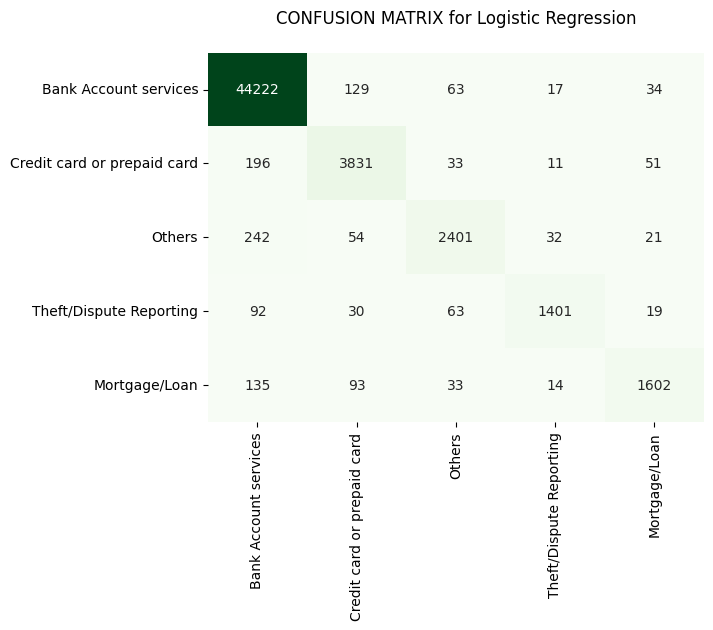

Accuracy   : 0.9751545996825918


In [10]:
from sklearn.linear_model import LogisticRegression
logistic_regression = LogisticRegression(solver='lbfgs', max_iter=1000)
logistic_regression.fit(xtrain, ytrain)

ytrain_pred = logistic_regression.predict(xtrain)
ytest_pred = logistic_regression.predict(xtest)

print("Training data accuracy\n")
training_accuracy = accuracy_evaluation(ytrain.values,ytrain_pred,'Logistic Regression')

Test data accuracy

CLASSIFICATION REPORT for Logistic Regression

                             precision    recall  f1-score   support

      Bank Account services       0.99      0.99      0.99     19057
Credit card or prepaid card       0.91      0.92      0.91      1767
                     Others       0.91      0.85      0.88      1178
    Theft/Dispute Reporting       0.92      0.88      0.90       687
              Mortgage/Loan       0.93      0.86      0.89       805

                   accuracy                           0.97     23494
                  macro avg       0.93      0.90      0.91     23494
               weighted avg       0.97      0.97      0.97     23494



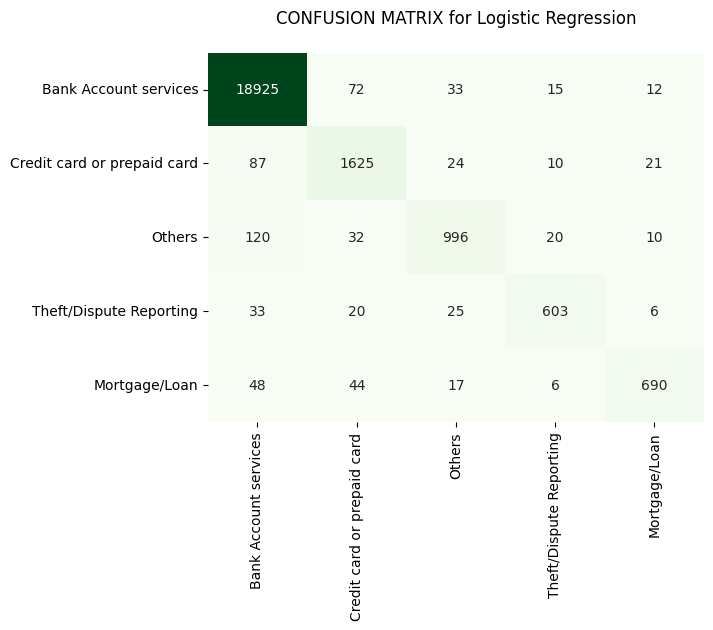

Accuracy   : 0.9721205414148293


In [11]:
print("Test data accuracy\n")
test_accuracy = accuracy_evaluation(ytest.values,ytest_pred,'Logistic Regression')

In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.naive_bayes import MultinomialNB
model_name = 'NAIVE BAYES'
nb = MultinomialNB()
nb.fit(xtrain, ytrain)
y_pred_nb = nb.predict(xtest)

In [14]:
# Hyperparameter tuning for best result
param_nb = {
    'alpha': (1, 0.1, 0.01, 0.001, 0.0001, 0.00001),
    'fit_prior':[True, False]
}

grid_nb = GridSearchCV(estimator=nb, 
                       param_grid=param_nb,
                       verbose=1,
                       scoring='f1_weighted',
                       n_jobs=-1,
                       cv=10)
grid_nb.fit(xtrain, ytrain)
print(grid_nb.best_params_)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
{'alpha': 1, 'fit_prior': False}


In [15]:
# Creating model with best hyperparameter
model_name = 'NAIVE BAYES'
nb_tuned = MultinomialNB(alpha=1,fit_prior=False)
nb_tuned.fit(xtrain, ytrain)
ypred_train_nb_tuned = nb_tuned.predict(xtrain)
ypred_test_nb_tuned = nb_tuned.predict(xtest)

In [16]:
# Calculate F1 Score of model using weighted average method
f1_nb = metrics.f1_score(ytrain.values, ypred_train_nb_tuned, average="weighted")
print("Training f1_score : {}".format(f1_nb))

# Calculate F1 Score of model using weighted average method
f1_nb = metrics.f1_score(ytest.values, ypred_test_nb_tuned, average="weighted")
print("Test f1_score : {}".format(f1_nb))

Training f1_score : 0.9565694857106763
Test f1_score : 0.954716327145995


Training Accuracy

CLASSIFICATION REPORT for Naive Bayes

                             precision    recall  f1-score   support

      Bank Account services       0.99      0.99      0.99     44465
Credit card or prepaid card       0.88      0.84      0.86      4122
                     Others       0.80      0.86      0.83      2750
    Theft/Dispute Reporting       0.72      0.78      0.74      1605
              Mortgage/Loan       0.77      0.81      0.79      1877

                   accuracy                           0.96     54819
                  macro avg       0.83      0.85      0.84     54819
               weighted avg       0.96      0.96      0.96     54819



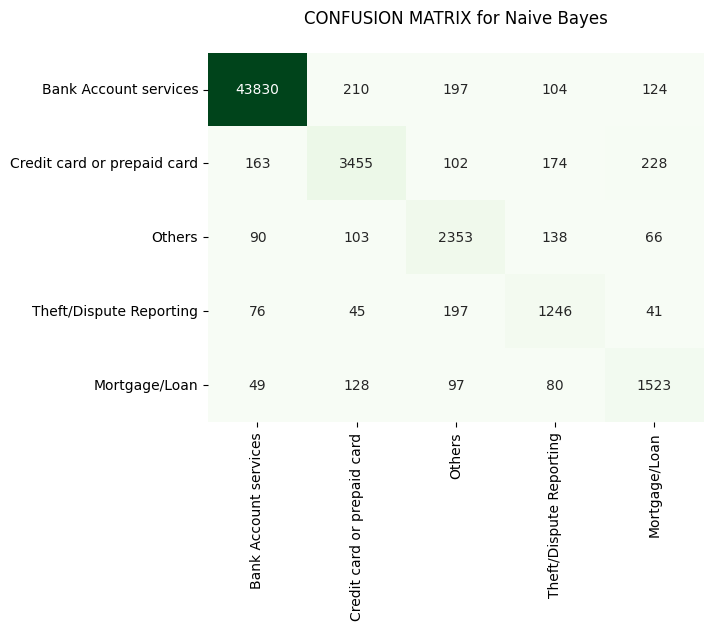

Accuracy   : 0.9560006567066163


In [17]:
# Evaluate the Naive Bayes classifier
print("Training Accuracy\n")
Training_acc = accuracy_evaluation(ytrain.values, ypred_train_nb_tuned, "Naive Bayes")

Test Accuracy

CLASSIFICATION REPORT for Naive Bayes

                             precision    recall  f1-score   support

      Bank Account services       0.99      0.98      0.99     19057
Credit card or prepaid card       0.88      0.83      0.85      1767
                     Others       0.80      0.83      0.82      1178
    Theft/Dispute Reporting       0.70      0.80      0.75       687
              Mortgage/Loan       0.74      0.81      0.78       805

                   accuracy                           0.95     23494
                  macro avg       0.82      0.85      0.84     23494
               weighted avg       0.96      0.95      0.95     23494



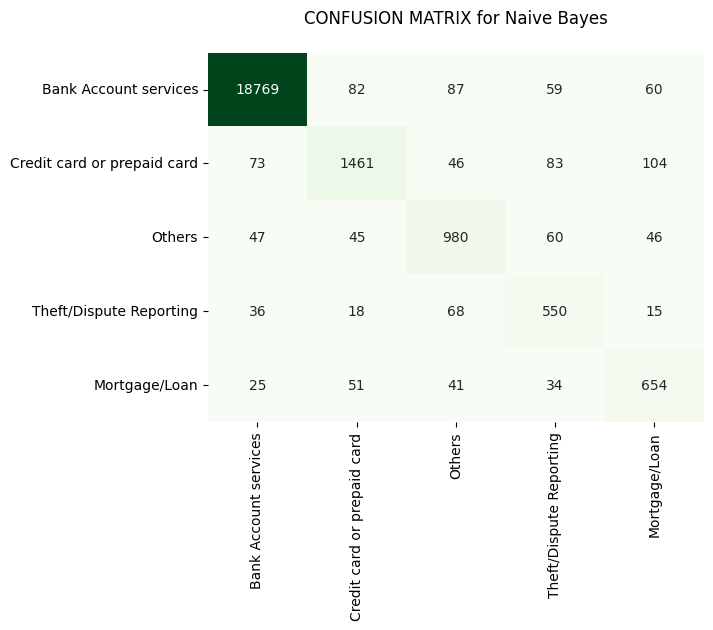

Accuracy   : 0.9540308163786498


In [18]:
# Evaluate the Naive Bayes classifier
print("Test Accuracy\n")
Test_acc = accuracy_evaluation(ytest.values, ypred_test_nb_tuned, "Naive Bayes")

Train Accuracy
CLASSIFICATION REPORT for Decision Tree Classifier

                             precision    recall  f1-score   support

      Bank Account services       1.00      0.95      0.97     44465
Credit card or prepaid card       0.78      0.88      0.82      4122
                     Others       0.68      0.86      0.76      2750
    Theft/Dispute Reporting       0.71      0.91      0.80      1605
              Mortgage/Loan       0.68      0.87      0.77      1877

                   accuracy                           0.93     54819
                  macro avg       0.77      0.89      0.82     54819
               weighted avg       0.95      0.93      0.94     54819



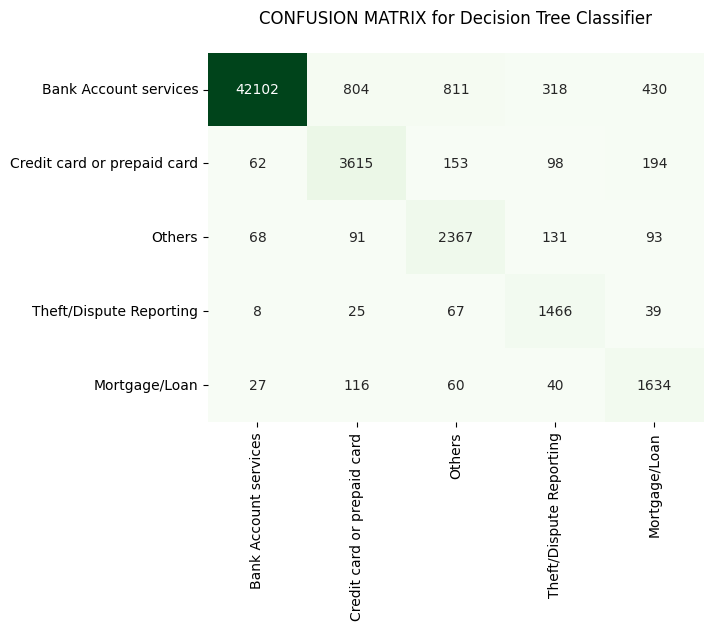

Accuracy   : 0.9336908736022183


In [19]:
from sklearn.tree import DecisionTreeClassifier

# Checking initial tree with standard params
dt = DecisionTreeClassifier(random_state=40, max_depth=10, min_samples_leaf = 10, class_weight="balanced")
dt.fit(xtrain,ytrain)

# predict the train and test
ytrain_pred_dt  = dt.predict(xtrain)
ytest_pred_dt = dt.predict(xtest)

# check for model accuracy
print("Train Accuracy")
train_accuracy = accuracy_evaluation(ytrain.values, ytrain_pred_dt,"Decision Tree Classifier")

Test Accuracy
CLASSIFICATION REPORT for Decision Tree Classifier

                             precision    recall  f1-score   support

      Bank Account services       1.00      0.95      0.97     19057
Credit card or prepaid card       0.74      0.84      0.79      1767
                     Others       0.63      0.80      0.71      1178
    Theft/Dispute Reporting       0.66      0.82      0.73       687
              Mortgage/Loan       0.65      0.80      0.72       805

                   accuracy                           0.92     23494
                  macro avg       0.74      0.84      0.78     23494
               weighted avg       0.94      0.92      0.93     23494



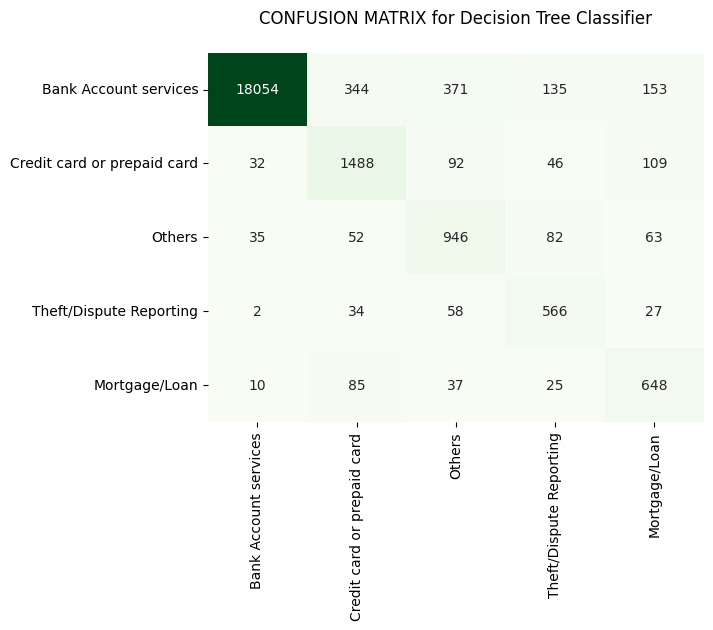

Accuracy   : 0.9237252064356857


In [20]:
# test data accuracy
print("Test Accuracy")
test_accuracy_dt = accuracy_evaluation(ytest.values,ytest_pred_dt,"Decision Tree Classifier")

In [21]:
dt = DecisionTreeClassifier(random_state = 40, class_weight="balanced")

# Create the parameter grid based on the results of random search 
params = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [5, 10, 20, 50],
    'criterion': ["entropy", "gini"]
}

grid_search = GridSearchCV(estimator = dt,param_grid = params,cv = 5, n_jobs=-1, verbose=1, scoring="accuracy", return_train_score=True)

grid_search.fit(xtrain, ytrain)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=40),
             n_jobs=-1,
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [5, 10, 15, 20],
                         'min_samples_leaf': [5, 10, 20, 50]},
             return_train_score=True, scoring='accuracy', verbose=1)

In [22]:
# Get the results in tabular format
scores = grid_search.cv_results_
pd.DataFrame(scores).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,3.291614,0.037577,0.038359,0.009567,entropy,5,5,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.873677,0.881430,...,0.881319,0.004416,29,0.883936,0.883343,0.884323,0.884118,0.884850,0.884114,0.000492
1,3.247489,0.058454,0.035569,0.001956,entropy,5,10,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.873586,0.881430,...,0.881300,0.004447,30,0.883753,0.883343,0.884209,0.884118,0.884805,0.884046,0.000487
2,3.246915,0.044532,0.037570,0.002228,entropy,5,20,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.874863,0.881613,...,0.881683,0.004047,28,0.884073,0.883092,0.884209,0.884004,0.884805,0.884037,0.000550
3,3.324753,0.096942,0.039889,0.003063,entropy,5,50,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.872401,0.880336,...,0.879458,0.004133,32,0.881883,0.880515,0.881769,0.881564,0.881863,0.881519,0.000515
4,5.301532,0.203641,0.053960,0.006407,entropy,10,5,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.914174,0.932050,...,0.921560,0.006996,14,0.931296,0.947144,0.934352,0.934511,0.943520,0.938165,0.006072


In [23]:
grid_search.best_params_

{'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 5}

In [24]:
dt_best = DecisionTreeClassifier(random_state=40, max_depth = 20, min_samples_leaf = 10, class_weight="balanced")
dt_best.fit(xtrain,ytrain)

ytrain_pred_dt = dt_best.predict(xtrain)
ytest_pred_dt = dt_best.predict(xtest)

Training Data evaluation
CLASSIFICATION REPORT for DT Classifier Tuned

                             precision    recall  f1-score   support

      Bank Account services       1.00      0.95      0.98     44465
Credit card or prepaid card       0.81      0.90      0.86      4122
                     Others       0.73      0.89      0.80      2750
    Theft/Dispute Reporting       0.70      0.93      0.80      1605
              Mortgage/Loan       0.73      0.90      0.81      1877

                   accuracy                           0.94     54819
                  macro avg       0.79      0.92      0.85     54819
               weighted avg       0.95      0.94      0.95     54819



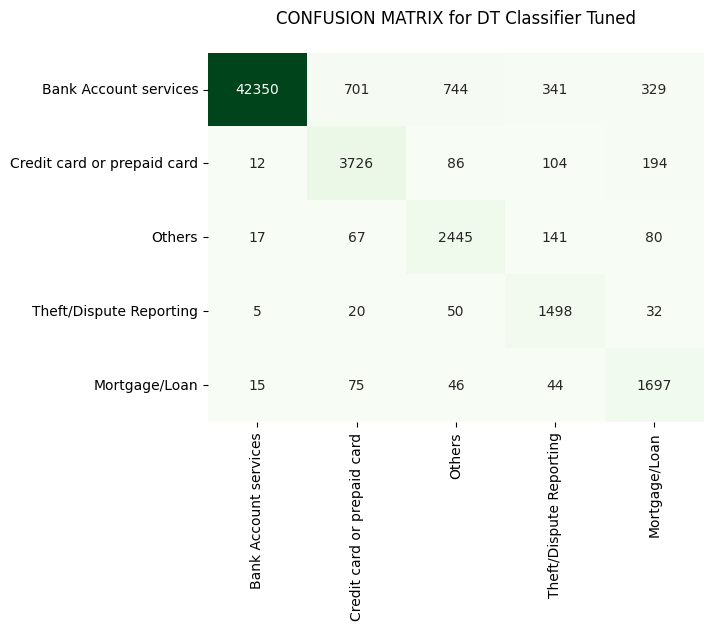

Accuracy   : 0.9433955380433792


In [25]:
print("Training Data evaluation")
train_accuracy_dt = accuracy_evaluation(ytrain.values,ytrain_pred_dt,"DT Classifier Tuned")

test Data evaluation
CLASSIFICATION REPORT for DT Classifier Tuned

                             precision    recall  f1-score   support

      Bank Account services       1.00      0.95      0.97     19057
Credit card or prepaid card       0.75      0.85      0.80      1767
                     Others       0.65      0.80      0.72      1178
    Theft/Dispute Reporting       0.64      0.83      0.72       687
              Mortgage/Loan       0.68      0.81      0.74       805

                   accuracy                           0.93     23494
                  macro avg       0.74      0.85      0.79     23494
               weighted avg       0.94      0.93      0.93     23494



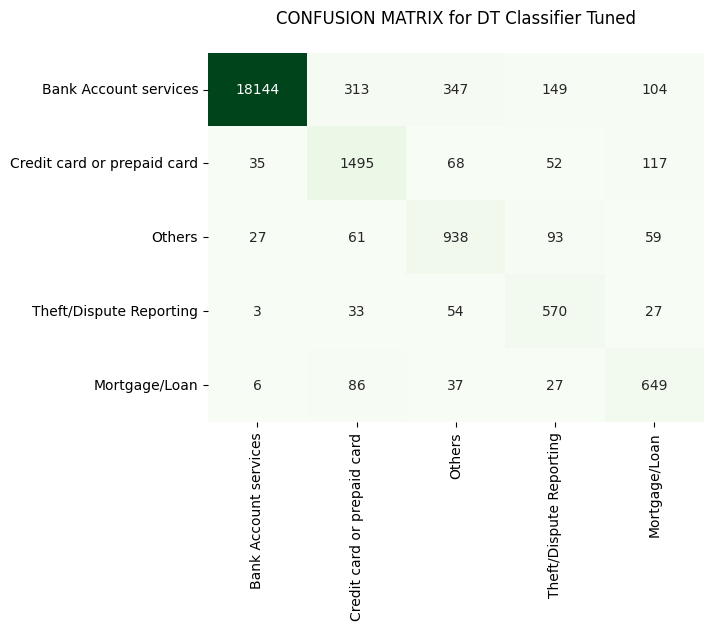

Accuracy   : 0.9277262279730996


In [26]:
print("test Data evaluation")
test_accuracy_dt = accuracy_evaluation(ytest.values,ytest_pred_dt,"DT Classifier Tuned")

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

In [28]:
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

folds = StratifiedKFold(n_splits=4, shuffle = True, random_state=40)

param_grid = {
     'max_depth': [5, 10, 20],
     'min_samples_leaf': [10, 20, 50, 100],
     'n_estimators': [15, 20, 25, 30],
     'min_samples_split': range(10, 30, 50),
     'max_features': [5, 10, 15],
     'criterion': ["gini"]
}

# Instantiate the grid search model
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, cv = folds, verbose = 1, scoring="accuracy", return_train_score=True)

In [29]:
# Fitting  grid search to the data
grid_search.fit(xtrain, ytrain)

Fitting 4 folds for each of 144 candidates, totalling 576 fits


GridSearchCV(cv=StratifiedKFold(n_splits=4, random_state=40, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'criterion': ['gini'], 'max_depth': [5, 10, 20],
                         'max_features': [5, 10, 15],
                         'min_samples_leaf': [10, 20, 50, 100],
                         'min_samples_split': range(10, 30, 50),
                         'n_estimators': [15, 20, 25, 30]},
             return_train_score=True, scoring='accuracy', verbose=1)

In [30]:
print(grid_search.best_score_)

rf_best = grid_search.best_estimator_
print(rf_best)

0.932432151244651
RandomForestClassifier(class_weight='balanced', max_depth=20, max_features=15,
                       min_samples_leaf=10, min_samples_split=10,
                       n_estimators=30, random_state=42)


In [31]:
rf_best.fit(xtrain,ytrain)

RandomForestClassifier(class_weight='balanced', max_depth=20, max_features=15,
                       min_samples_leaf=10, min_samples_split=10,
                       n_estimators=30, random_state=42)

In [32]:
ytrain_pred_rf = rf_best.predict(xtrain)
ytest_pred_rf = rf_best.predict(xtest)

Training Accuracy
CLASSIFICATION REPORT for Random Forest

                             precision    recall  f1-score   support

      Bank Account services       1.00      0.95      0.97     44465
Credit card or prepaid card       0.78      0.94      0.85      4122
                     Others       0.72      0.92      0.81      2750
    Theft/Dispute Reporting       0.78      0.95      0.85      1605
              Mortgage/Loan       0.81      0.90      0.85      1877

                   accuracy                           0.95     54819
                  macro avg       0.82      0.93      0.87     54819
               weighted avg       0.95      0.95      0.95     54819



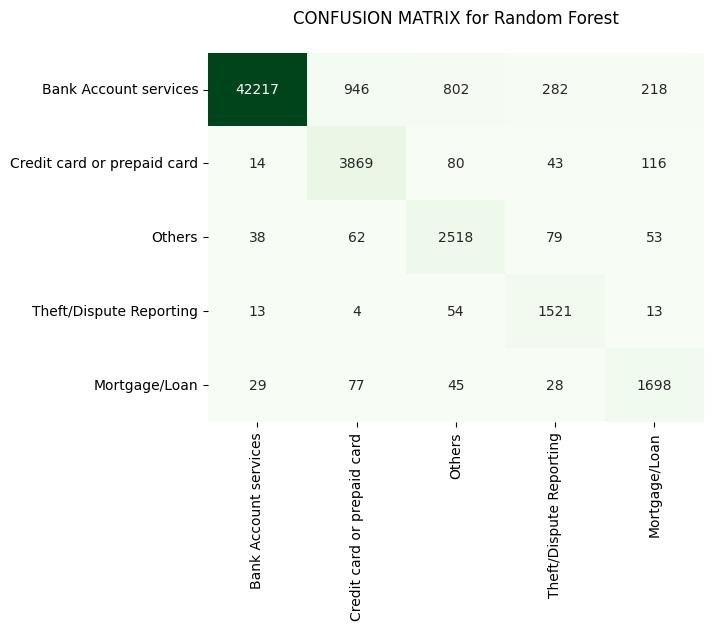

Accuracy   : 0.9453474160418833


In [33]:
print("Training Accuracy")

train_accuracy_rf = accuracy_evaluation(ytrain.values,ytrain_pred_rf,"Random Forest")

Test Accuracy
CLASSIFICATION REPORT for Random Forest

                             precision    recall  f1-score   support

      Bank Account services       1.00      0.95      0.97     19057
Credit card or prepaid card       0.75      0.89      0.82      1767
                     Others       0.66      0.86      0.75      1178
    Theft/Dispute Reporting       0.71      0.87      0.78       687
              Mortgage/Loan       0.76      0.84      0.80       805

                   accuracy                           0.93     23494
                  macro avg       0.78      0.88      0.82     23494
               weighted avg       0.95      0.93      0.94     23494



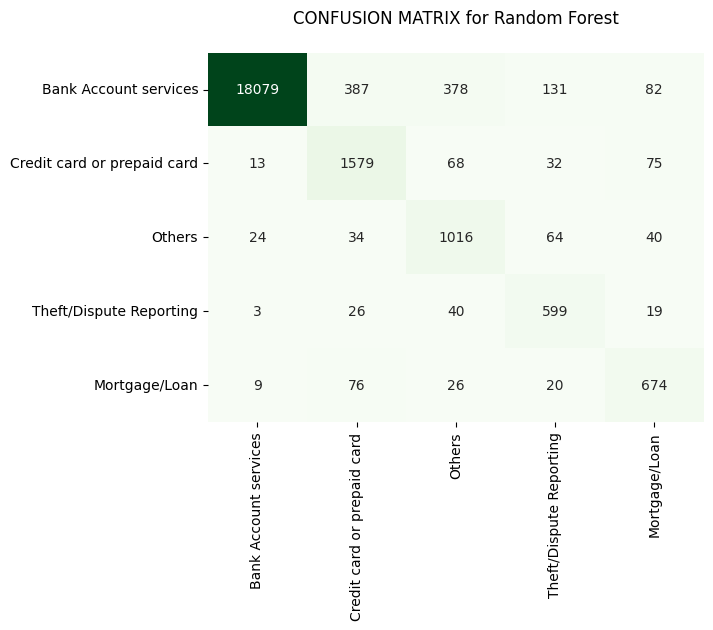

Accuracy   : 0.9341534008683068


In [34]:
print("Test Accuracy")

test_accuracy_rf = accuracy_evaluation(ytest.values,ytest_pred_rf,"Random Forest")

In [35]:
Topic_names_index = {
    0: "Bank account services",
    1: "Credit Card/Prepaid Card",
    2: "Mortgages/loans",
    3: "Theft/Dispute reporting",
    4: "Others"
}


In [36]:
def Topic_Predictor(sentence, model=nmf_model, count_vector=count_vector, tfidf_transformer=tfidf_transformer):
    # Transform the new sentence using the same CountVectorizer used during training
    vect_custom = count_vector.transform(pd.Series(sentence))  # This uses the same trained CountVectorizer
    
    # Transform the word vector using the same TF-IDF transformer that was used during training
    word_vect_custom = tfidf_transformer.transform(vect_custom)  # This uses the same trained TfidfTransformer
    
    # Get the topic distribution (W) for the new sentence using the trained NMF model
    topic_distribution = model.transform(word_vect_custom)  # This gives the topic distribution
    
    # Get the topic with the highest distribution (index of max topic)
    predicted_topic_index = np.argmax(topic_distribution)
    
    # Map the predicted topic index to the topic name (assuming Topic_names is defined)
    return Topic_names_index[predicted_topic_index]  # Topic_names_index should map indices to topic names


In [51]:
import pandas as pd

# Set display options to show everything (no truncation)
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Auto-adjust width
pd.set_option('display.max_colwidth', None)  # Show full column width

# Now display the DataFrame
custom_text = pd.DataFrame({
    'complaints': [
        "I can not get from chase who services my mortgage, who owns it and who has original loan docs", 
        "The bill amount of my credit card was debited twice. Please look into the matter and resolve at the earliest.",
        "I want to open a salary account at your downtown branch. Please provide me the procedure.",
        "Unwanted service activated and money deducted automatically",
        "How can I know my CIBIL score?",
        "Where are the bank branches in the city of Patna?",
        "This letter is to dispute an incorrectly charged amount on my credit card. My credit card number is XCXCXXC and it has a constant charge",
        "I want to report an incident of theft of my credit card.",
        "I would like to convert my account into a premium account to avail latest benefits.",
        "I am buying a new house, based on my current salary I should get a good loan."
    ]
})

# Now everything will be visible
print(custom_text)


                                                                                                                                 complaints
0                                             I can not get from chase who services my mortgage, who owns it and who has original loan docs
1                             The bill amount of my credit card was debited twice. Please look into the matter and resolve at the earliest.
2                                                 I want to open a salary account at your downtown branch. Please provide me the procedure.
3                                                                               Unwanted service activated and money deducted automatically
4                                                                                                            How can I know my CIBIL score?
5                                                                                         Where are the bank branches in the city of Patna?
6  This letter is to

In [53]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import NMF
import numpy as np

# Set display options to show everything (no truncation)
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Auto-adjust width
pd.set_option('display.max_colwidth', None)  # Show full column width

# Example custom_text list with 9 complaints
custom_text = [
    "I can not get from chase who services my mortgage, who owns it and who has original loan docs", 
    "The bill amount of my credit card was debited twice. Please look into the matter and resolve at the earliest.",
    "I want to open a salary account at your downtown branch. Please provide me the procedure.",
    "Unwanted service activated and money deducted automatically",
    "How can I know my CIBIL score?",
    "Where are the bank branches in the city of Patna?",
    "This letter is to dispute an incorrectly charged amount on my credit card. My credit card number is XCXCXXC and it has a constant charge",
    "I want to report an incident of theft of my credit card.",
    "I would like to convert my account into a premium account to avail latest benefits."
]

# Convert custom_text to a DataFrame with a 'complaints' column
custom_text_df = pd.DataFrame(custom_text, columns=['complaints'])

# Define the number of topics you want
num_topics = 3

# Use CountVectorizer with custom_text to create the vocabulary
count_vector_custom = CountVectorizer(ngram_range=(1, 3), stop_words='english', max_df=0.95, min_df=0.02)
vector_custom = count_vector_custom.fit_transform(custom_text_df['complaints'])

# Apply the TF-IDF transformer
tfidf_transformer_custom = TfidfTransformer(use_idf=True).fit(vector_custom)
word_vect_custom = tfidf_transformer_custom.transform(vector_custom)

# Train a new NMF model on this data
new_nmf_model = NMF(n_components=num_topics, random_state=40)
W_custom = new_nmf_model.fit_transform(word_vect_custom)  # New Document-Topic matrix

# Get the topic distribution
topic_distribution_custom = new_nmf_model.transform(word_vect_custom)

# Extract the top words for each topic
num_top_words = 5  # Number of words to show for each topic
feature_names = count_vector_custom.get_feature_names_out()

# Get the top words for each topic
top_words = []
for topic_idx, topic in enumerate(new_nmf_model.components_):
    top_idx = topic.argsort()[:-num_top_words - 1:-1]
    top_words.append([feature_names[i] for i in top_idx])

# Map each complaint to its predicted topic (based on highest probability)
predicted_topic_index_custom = np.argmax(topic_distribution_custom, axis=1)

# Define the mapping of topic indices to human-readable labels
topic_labels = {
    0: "Bank account services",
    1: "Credit Card/Prepaid Card",
    2: "Mortgages/loans",
    3: "Theft/Dispute reporting",
    4: "Others"
}

# Map the numeric topic predictions to the human-readable labels
custom_text_df['predicted topic'] = [topic_labels.get(topic_idx, "Unknown") for topic_idx in predicted_topic_index_custom]

# Display the updated dataframe with predicted topic labels
print(custom_text_df)


                                                                                                                                 complaints  \
0                                             I can not get from chase who services my mortgage, who owns it and who has original loan docs   
1                             The bill amount of my credit card was debited twice. Please look into the matter and resolve at the earliest.   
2                                                 I want to open a salary account at your downtown branch. Please provide me the procedure.   
3                                                                               Unwanted service activated and money deducted automatically   
4                                                                                                            How can I know my CIBIL score?   
5                                                                                         Where are the bank branches in the city of Patna?   

In [52]:
import tkinter as tk
from tkinter import messagebox
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import NMF
import numpy as np

# Simulating the existing custom_text and NMF model for demonstration purposes
custom_text = [
    "I am having trouble with my internet connection",
    "The app is crashing frequently",
    "I received a wrong order",
    "The website is slow",
    "My phone's battery drains too fast"
]
num_topics = 3  # Define the number of topics you want

# Use CountVectorizer with custom_text to create the vocabulary
count_vector_custom = CountVectorizer(ngram_range=(1, 3), stop_words='english', max_df=0.95, min_df=0.02)
vector_custom = count_vector_custom.fit_transform(custom_text)

# Apply the TF-IDF transformer
tfidf_transformer_custom = TfidfTransformer(use_idf=True).fit(vector_custom)
word_vect_custom = tfidf_transformer_custom.transform(vector_custom)

# Train NMF model
new_nmf_model = NMF(n_components=num_topics, random_state=40)
W_custom = new_nmf_model.fit_transform(word_vect_custom)  # Document-Topic matrix

# Define the mapping of topic indices to human-readable labels
topic_labels = {
    0: "Bank account services",
    1: "Credit Card/Prepaid Card",
    2: "Mortgages/loans",
    3: "Theft/Dispute reporting",
    4: "Others"
}

# Function to predict topic
def predict_topic():
    complaint = entry_complaint.get()  # Get the complaint input

    if complaint == "":
        messagebox.showwarning("Input Error", "Please enter a complaint.")
        return

    # Transform the new complaint using the same CountVectorizer and TF-IDF transformer
    vector_complaint = count_vector_custom.transform([complaint])
    tfidf_complaint = tfidf_transformer_custom.transform(vector_complaint)

    # Get the topic distribution
    topic_distribution_complaint = new_nmf_model.transform(tfidf_complaint)

    # Predict the topic with the highest probability
    predicted_topic_index = np.argmax(topic_distribution_complaint, axis=1)
    
    # Map the numeric topic prediction to a human-readable topic label
    predicted_topic_label = topic_labels.get(predicted_topic_index[0], "Unknown")

    # Show the predicted topic in a message box
    messagebox.showinfo("Predicted Topic", f"The predicted topic for this complaint is: {predicted_topic_label}")

# Create the GUI window
root = tk.Tk()
root.title("Complaint Topic Prediction")

# Add a label, text entry, and button
label_complaint = tk.Label(root, text="Enter your complaint:")
label_complaint.pack(pady=10)

entry_complaint = tk.Entry(root, width=50)
entry_complaint.pack(pady=10)

button_predict = tk.Button(root, text="Predict Topic", command=predict_topic)
button_predict.pack(pady=20)

# Start the Tkinter event loop
root.mainloop()
